In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
df = pd.read_excel("data/IV_40.xlsx")

y = df["Y"].values
x = df["X1"].values
z = df["Z1"].values
n = len(y)

In [4]:
df

,Y,X1,Z1
0,-2.522954,-5.143265,0
1,-6.510020,-7.265963,0
2,-2.675980,-5.279740,0
3,-2.088578,-4.693511,0
4,9.311424,9.319498,0
...,...,...,...
1495,-0.926497,0.605483,1
1496,1.169525,3.387240,1
1497,-0.360283,1.966911,1
1498,3.594734,6.008488,1


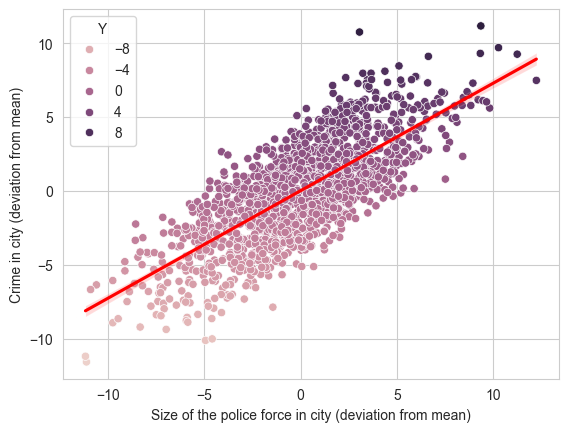

In [5]:
ax = sns.scatterplot(data=df, x="X1", y="Y", hue="Y")

sns.regplot(
    data=df,
    x="X1",
    y="Y",
    scatter=False,
    ax=ax,
    color="red"
)

plt.xlabel("Size of the police force in city (deviation from mean)")
plt.ylabel("Crime in city (deviation from mean)")

plt.show()

## 2.a

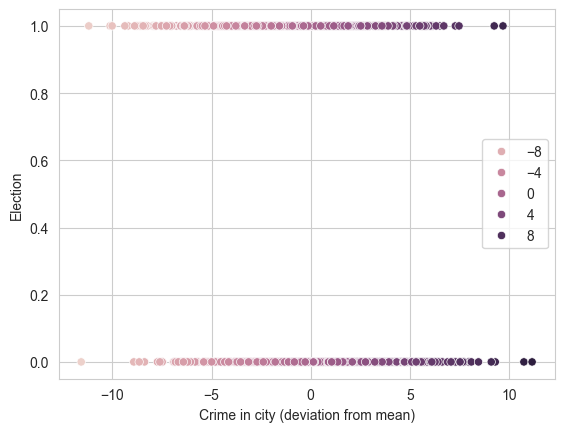

In [6]:
ax = sns.scatterplot(data=df, x="Y", y="Z1", hue="Y")
plt.xlabel("Crime in city (deviation from mean)")
plt.ylabel("Election")
ax.legend(loc="center right")
plt.show()

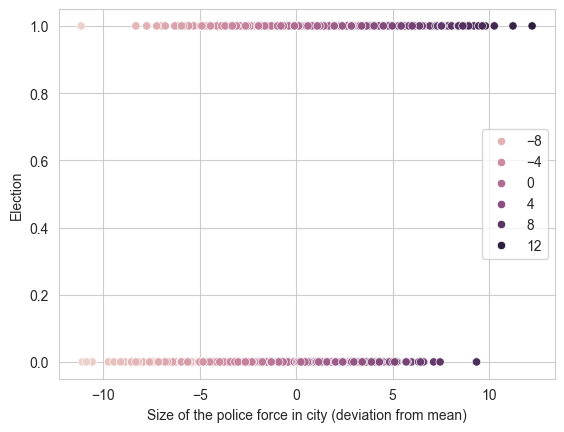

In [7]:
ax = sns.scatterplot(data=df, x="X1", y="Z1", hue="X1")
plt.xlabel("Size of the police force in city (deviation from mean)")
plt.ylabel("Election")
ax.legend(loc="center right")
plt.show()

## 2.b

In [8]:
Z_mat = sm.add_constant(z)
model = sm.OLS(x, Z_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     172.2
Date:                Sat, 02 May 2026   Prob (F-statistic):           2.55e-37
Time:                        17:57:50   Log-Likelihood:                -3893.0
No. Observations:                1500   AIC:                             7790.
Df Residuals:                    1498   BIC:                             7801.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2050      0.118    -10.170      0.0

## 2.c

In [9]:
pi0 = model.params[0]
pi1 = model.params[1]
v = x - pi0 - pi1 * z

In [10]:
X_mat = sm.add_constant(np.column_stack((x, v)))
model = sm.OLS(y, X_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     3740.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        17:57:50   Log-Likelihood:                -2608.0
No. Observations:                1500   AIC:                             5222.
Df Residuals:                    1497   BIC:                             5238.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1512      0.036     -4.229      0.0

## 2.d

In [11]:
z_bar = np.mean(z)
y_bar = np.mean(y)
x_bar = np.mean(x)

num = np.sum((z - z_bar) * (y - y_bar))
den = np.sum((z - z_bar) * (x - x_bar))

beta_iv = num / den

print(beta_iv)

-0.8218925476364212


In [12]:
y_1 = y[z == 1]
y_0 = y[z == 0]

x_1 = x[z == 1]
x_0 = x[z == 0]

beta_iv_alt = (np.mean(y_1) - np.mean(y_0)) / (np.mean(x_1) - np.mean(x_0))

print(beta_iv_alt)

-0.8218925476364213


## 2.e 2SLS

In [13]:
# Step 1: Get x_hat using z
x_hat = pi0 + pi1 * z

# Step 2: OLS for y using x_hat
X_mat = sm.add_constant(x_hat)  # adds intercept
model = sm.OLS(y, X_mat).fit()

beta_0_2SLS = model.params[0]
beta_1_2SLS = model.params[1]

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     115.9
Date:                Sat, 02 May 2026   Prob (F-statistic):           4.29e-26
Time:                        17:57:50   Log-Likelihood:                -3895.5
No. Observations:                1500   AIC:                             7795.
Df Residuals:                    1498   BIC:                             7806.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1512      0.084     -1.793      0.0

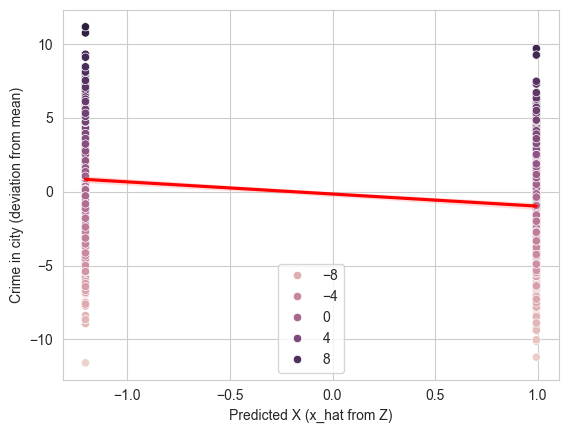

In [14]:
ax = sns.scatterplot(x=x_hat, y=y, hue=y)

sns.regplot(
    x=x_hat,
    y=y,
    scatter=False,
    ax=ax,
    color="red"
)

plt.xlabel("Predicted X (x_hat from Z)")
plt.ylabel("Crime in city (deviation from mean)")

plt.show()

## 2.f OLS

In [15]:
X_mat = sm.add_constant(x)
model = sm.OLS(y, X_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     1817.
Date:                Sat, 02 May 2026   Prob (F-statistic):          1.23e-260
Time:                        17:57:50   Log-Likelihood:                -3355.8
No. Observations:                1500   AIC:                             6716.
Df Residuals:                    1498   BIC:                             6726.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0125      0.059      0.214      0.8

## 2.g Sargan-Hansen test

In [16]:
u_hat = y - beta_0_2SLS - beta_1_2SLS * x

In [17]:
Z_mat = sm.add_constant(z)
model = sm.OLS(u_hat, Z_mat).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     0.000
Date:                Sat, 02 May 2026   Prob (F-statistic):               1.00
Time:                        17:57:50   Log-Likelihood:                -4758.4
No. Observations:                1500   AIC:                             9521.
Df Residuals:                    1498   BIC:                             9531.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -9.168e-15      0.211  -4.35e-14      1.0

In [18]:
r2 = model.rsquared

# Test statistic R^2 * n
tstat = r2 * n
print(tstat)

0.0


## 2.h Plausibly exogenous

In [22]:
# Adjust y with plausible exogenous instrument
gamma = 0.1
y_adj = y - gamma * z

# Step 1: Get x_hat using z
x_hat = pi0 + pi1 * z

# Step 2: OLS for y using x_hat
X_mat = sm.add_constant(x_hat)  # adds intercept
model = sm.OLS(y_adj, X_mat).fit()

beta_pe_0_2SLS = model.params[0]
beta_pe_1_2SLS = model.params[1]

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     129.1
Date:                Sat, 02 May 2026   Prob (F-statistic):           9.22e-29
Time:                        18:02:00   Log-Likelihood:                -3895.5
No. Observations:                1500   AIC:                             7795.
Df Residuals:                    1498   BIC:                             7806.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2060      0.084     -2.443      0.0